#**TASK 1:**
###TARGET DEFINATION:

  The target variable is income level. The positive class is defined as individuals earning more than $50K per year, while the negative class consists of individuals earning $50K or less. The target is converted to binary values where 1 = >50K and 0 = <=50K.

###Business Objective:

  The business objective is to identify people who are most likely to earn more than $50K per year so that outreach efforts can focus on people who are more likely to be valuable customers.

###Class Base Rate:

  The dataset contains 11,687 positive cases out of 48,842 observations, giving a positive-class base rate of 23.93%. This means approximately 24% of the individuals in the dataset earn more than $50K per year.

###Primary Evaluation Metric: Precision

  Precision is selected as the primary evaluation metric because the business wants to minimize wasted outreach. In practical terms, precision tells us how often people identified as potential high-income customers actually belong to the >$50K group. We will also monitor recall because focusing too strongly on precision could cause the model to miss a large number of genuine high-income customers.

###Stakeholder Explanation:

  The goal is to identify people who are most likely to earn more than $50K per year so the business can focus its outreach on the people most likely to be valuable customers. We will prioritize precision, meaning that most people we select should genuinely fit our target group, helping reduce wasted marketing effort and cost. We will also monitor recall, which tells us how many of the genuinely high-income people we successfully identify, so that we do not become so selective that we miss too many potential customers.

  

#**TASK 2**

###**libraries import and dataset load**

In [35]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


adult = fetch_openml(
    'adult',
    version=2,
    as_frame=True
)

df = adult.frame


###**Dataset overview**

In [2]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.shape

(48842, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [7]:
df['class'].value_counts()

,count
class,
<=50K,37155
>50K,11687


###**Target convert to binary**

In [47]:
df['income'] = (df['class'] == '>50K').astype(int)

In [9]:
positive_rate = df['income'].mean()

print(f"People earning >50K: {positive_rate:.2%}")

People earning >50K: 23.93%


In [48]:
df['income'].value_counts()

,count
income,
0,37155
1,11687


**Missing value**

In [10]:
(df == '?').sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [18]:
df = df.replace('?', np.nan)
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [21]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percentage': df.isna().mean() * 100
})

missing_summary = missing_summary[
    missing_summary['Missing Count'] > 0
].sort_values(
    'Missing Count',
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
occupation,2809,5.751198
workclass,2799,5.730724
native-country,857,1.754637


**Numeric summary**

In [22]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [23]:
numeric_features = [
    col for col in numeric_cols
    if col != 'income'
]

numeric_features

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [24]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


**Categirical Column**

In [26]:
categorical_cols = df.select_dtypes(
    include=['object', 'category']
).columns

categorical_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'class'],
      dtype='object')

In [27]:
categorical_features = [
    col for col in categorical_cols
    if col != 'class'
]

categorical_features

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [29]:
df['education'].value_counts()


,count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [30]:
df['workclass'].value_counts(dropna=False)

,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
NaN,2799
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


In [31]:
df['workclass'].value_counts(dropna=False)

,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
NaN,2799
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


In [32]:
df['marital-status'].value_counts()

,count
marital-status,
Married-civ-spouse,22379
Never-married,16117
Divorced,6633
Separated,1530
Widowed,1518
Married-spouse-absent,628
Married-AF-spouse,37


**Visualization**

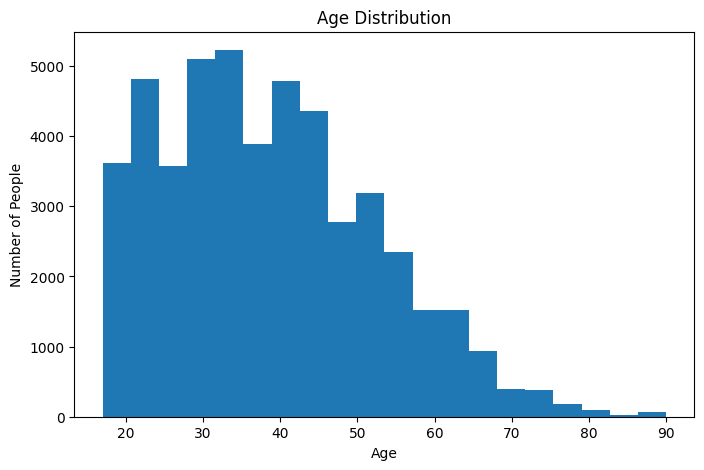

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of People')

plt.show()

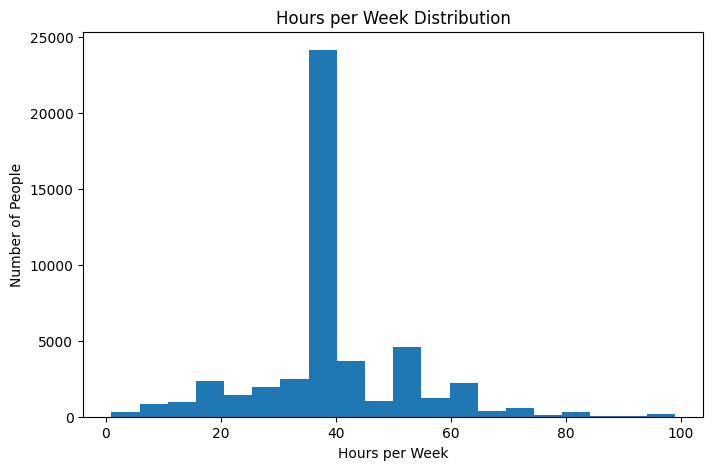

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(df['hours-per-week'], bins=20)

plt.title('Hours per Week Distribution')
plt.xlabel('Hours per Week')
plt.ylabel('Number of People')

plt.show()

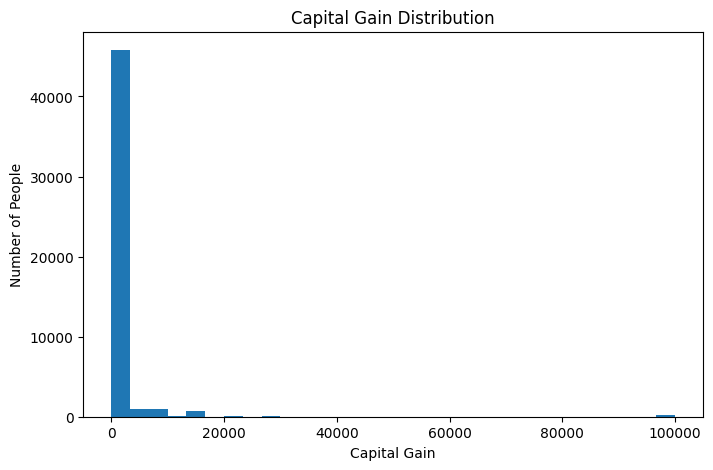

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(df['capital-gain'], bins=30)

plt.title('Capital Gain Distribution')
plt.xlabel('Capital Gain')
plt.ylabel('Number of People')

plt.show()

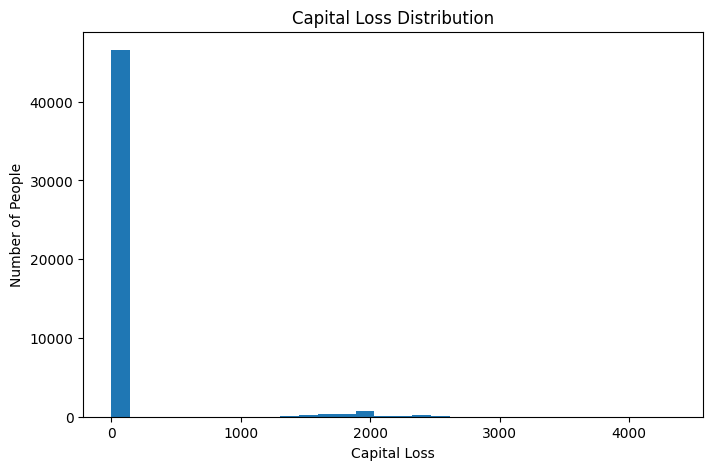

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(df['capital-loss'], bins=30)

plt.title('Capital Loss Distribution')
plt.xlabel('Capital Loss')
plt.ylabel('Number of People')

plt.show()

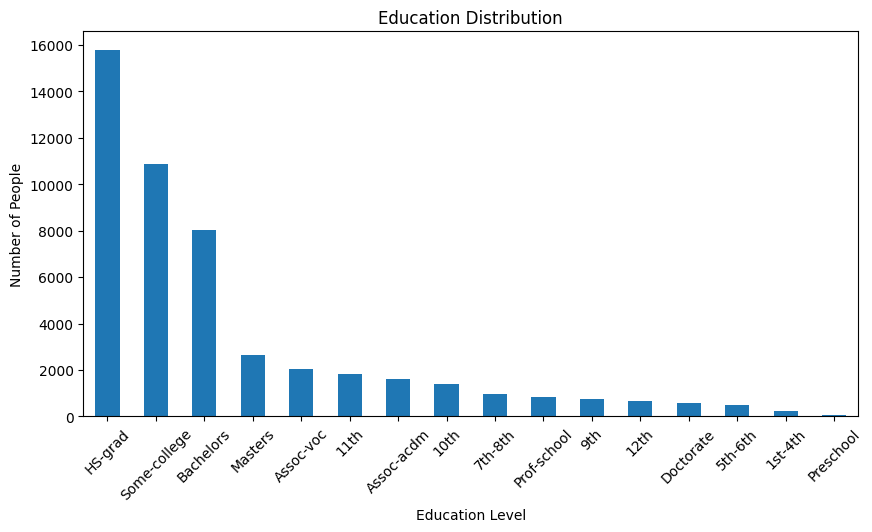

In [40]:
plt.figure(figsize=(10, 5))

df['education'].value_counts().plot(kind='bar')

plt.title('Education Distribution')
plt.xlabel('Education Level')
plt.ylabel('Number of People')

plt.xticks(rotation=45)

plt.show()

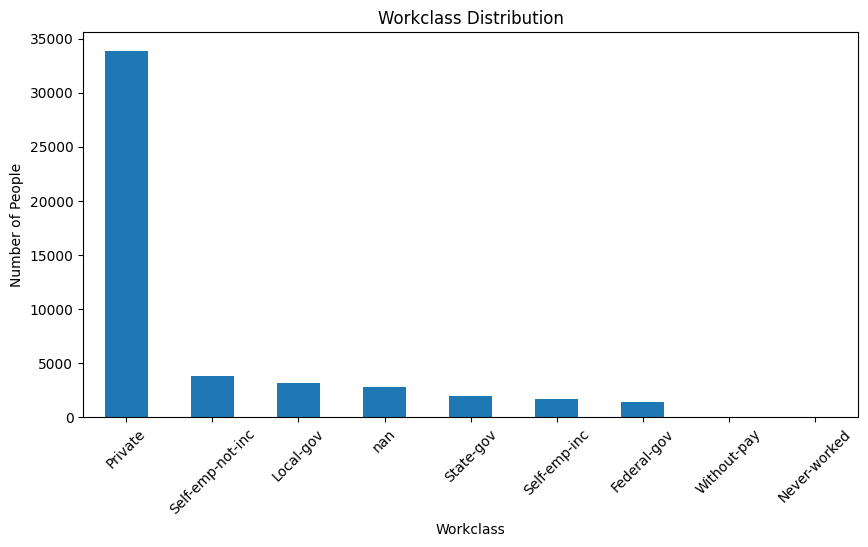

In [41]:
plt.figure(figsize=(10, 5))

df['workclass'].value_counts(dropna=False).plot(kind='bar')

plt.title('Workclass Distribution')
plt.xlabel('Workclass')
plt.ylabel('Number of People')

plt.xticks(rotation=45)

plt.show()

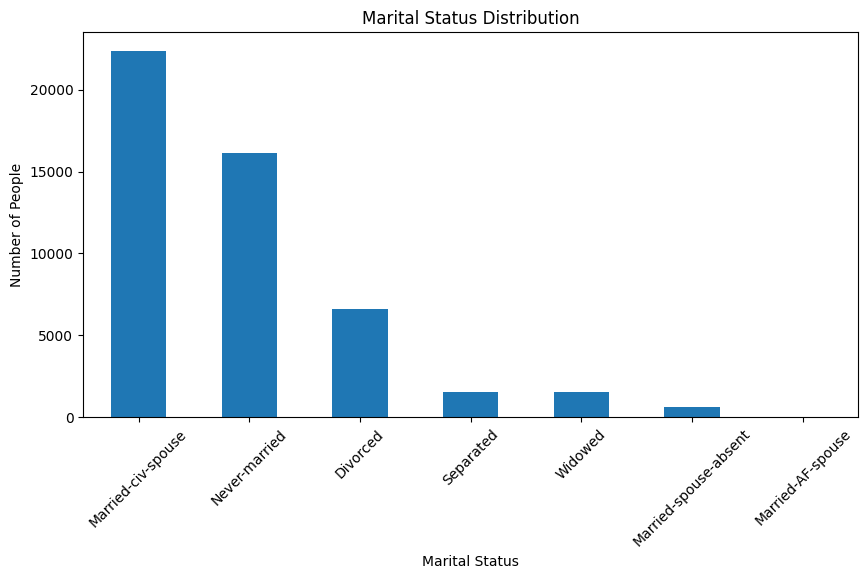

In [42]:
plt.figure(figsize=(10, 5))

df['marital-status'].value_counts().plot(kind='bar')

plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Number of People')

plt.xticks(rotation=45)

plt.show()

**Summary table**

In [43]:
feature_summary = pd.DataFrame({
    'Feature': [
        'Age',
        'Hours per Week',
        'Education-num',
        'Capital Gain',
        'Capital Loss'
    ],
    'Mean': [
        df['age'].mean(),
        df['hours-per-week'].mean(),
        df['education-num'].mean(),
        df['capital-gain'].mean(),
        df['capital-loss'].mean()
    ],
    'Median': [
        df['age'].median(),
        df['hours-per-week'].median(),
        df['education-num'].median(),
        df['capital-gain'].median(),
        df['capital-loss'].median()
    ],
    'Minimum': [
        df['age'].min(),
        df['hours-per-week'].min(),
        df['education-num'].min(),
        df['capital-gain'].min(),
        df['capital-loss'].min()
    ],
    'Maximum': [
        df['age'].max(),
        df['hours-per-week'].max(),
        df['education-num'].max(),
        df['capital-gain'].max(),
        df['capital-loss'].max()
    ]
})

feature_summary

,Feature,Mean,Median,Minimum,Maximum
0,Age,38.643585,37.0,17,90
1,Hours per Week,40.422382,40.0,1,99
2,Education-num,10.078089,10.0,1,16
3,Capital Gain,1079.067626,0.0,0,99999
4,Capital Loss,87.502314,0.0,0,4356


summary_table = pd.DataFrame({
    'Measure': [
        'Negative class (<=50K)',
        'Positive class (>50K)',
        'Positive class rate',
        'Age',
        'Hours per week',
        'Education-num',
        'Capital gain',
        'Capital loss'
    ],
    'Value': [
        (df['income'] == 0).sum(),
        (df['income'] == 1).sum(),
        f"{df['income'].mean():.2%}",
        'Median = 37, Range = 17–90',
        'Median = 40, Range = 1–99',
        'Median = 10, Range = 1–16',
        'Median = 0, Maximum = 99,999',
        'Median = 0, Maximum = 4,356'
    ]
})

summary_table

# **TASK 3**

In [49]:
X = df.drop(columns=['class', 'income'])
y = df['income']

X → information about the person
y → actual income class

### Split into 80% train and 20% test set

In [52]:
from sklearn.model_selection import train_test_split
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [53]:
print("Development set:", X_dev.shape)
print("Test set:", X_test.shape)

print("\nPositive rates:")
print("Development:", y_dev.mean())
print("Test:", y_test.mean())

Development set: (39073, 14)
Test set: (9769, 14)

Positive rates:
Development: 0.23927008420136667
Test: 0.23932848807452145


In [54]:
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.125,
    stratify=y_dev,
    random_state=42
)

### Split the Train into 70% train and 10% dev

In [56]:
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nPositive rates:")
print("Training:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Training set: (34188, 14)
Validation set: (4885, 14)
Test set: (9769, 14)

Positive rates:
Training: 0.23926523926523927
Validation: 0.23930399181166837
Test: 0.23932848807452145


### Why a Hold-out Test Set Is Necessary

The hold-out test set gives us a fair estimate of how well our final model will perform on new people it has never seen before. If we use the test set while choosing or tuning the model, we may unintentionally adjust the model to perform well on that specific test data, making its reported performance look better than it would be in the real world.


#**Task 4**

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

### Baseline 1 Majority class

In [58]:
y_train.value_counts()

,count
income,
0,26008
1,8180


In [63]:
majority_class = y_train.mode()[0]

y_pred_majority = [majority_class] * len(y_test)

In [60]:
majority_accuracy = accuracy_score(y_test, y_pred_majority)
majority_precision = precision_score(y_test, y_pred_majority, zero_division=0)
majority_recall = recall_score(y_test, y_pred_majority, zero_division=0)
majority_f1 = f1_score(y_test, y_pred_majority, zero_division=0)

print("Accuracy:", majority_accuracy)
print("Precision:", majority_precision)
print("Recall:", majority_recall)
print("F1:", majority_f1)

Accuracy: 0.7606715119254785
Precision: 0.0
Recall: 0.0
F1: 0.0


In [61]:
majority_score = y_train.mean()

y_score_majority = [majority_score] * len(y_test)

majority_roc_auc = roc_auc_score(y_test, y_score_majority)
majority_pr_auc = average_precision_score(y_test, y_score_majority)

print("ROC AUC:", majority_roc_auc)
print("PR AUC:", majority_pr_auc)

ROC AUC: 0.5
PR AUC: 0.23932848807452145


In [62]:
cm_majority = confusion_matrix(y_test, y_pred_majority)

cm_majority

array([[7431,    0],
       [2338,    0]])

### **Baseline 2**

In [64]:
y_pred_rule = (X_test['education-num'] >= 13).astype(int)

In [65]:
y_pred_rule.value_counts()

,count
education-num,
0,7370
1,2399


In [66]:
rule_accuracy = accuracy_score(y_test, y_pred_rule)
rule_precision = precision_score(y_test, y_pred_rule, zero_division=0)
rule_recall = recall_score(y_test, y_pred_rule, zero_division=0)
rule_f1 = f1_score(y_test, y_pred_rule, zero_division=0)

rule_roc_auc = roc_auc_score(y_test, y_pred_rule)
rule_pr_auc = average_precision_score(y_test, y_pred_rule)

print("Accuracy:", rule_accuracy)
print("Precision:", rule_precision)
print("Recall:", rule_recall)
print("F1:", rule_f1)
print("ROC AUC:", rule_roc_auc)
print("PR AUC:", rule_pr_auc)

Accuracy: 0.7529941652165012
Precision: 0.484368486869529
Recall: 0.49700598802395207
F1: 0.4906058686932658
ROC AUC: 0.6652705892212346
PR AUC: 0.3611148347810222


In [67]:
cm_rule = confusion_matrix(y_test, y_pred_rule)

print(cm_rule)

[[6194 1237]
 [1176 1162]]


In [68]:
print("Actual positive cases:", y_test.sum())
print("Predicted positive cases:", y_pred_rule.sum())

Actual positive cases: 2338
Predicted positive cases: 2399


### Baseline Interpretation

The education-based rule is the stronger baseline because, unlike the majority-class predictor, it can identify people who earn more than $50K. Although the majority-class baseline has slightly higher accuracy (76.07% vs. 75.30%), it has 0% precision, 0% recall, and an F1 score of 0 because it never predicts the positive class. The education rule achieves 48.44% precision and 49.70% recall, meaning that it correctly identifies nearly half of the high-income individuals while avoiding unnecessary outreach for about half of the contacted group. A useful real model should therefore substantially exceed the education rule's 48.44% precision while maintaining reasonable recall, rather than simply improving overall accuracy.


### **TASK 5**

In [69]:
error_analysis = X_test.copy()

error_analysis['actual_income'] = y_test
error_analysis['predicted_income'] = y_pred_rule

false_positives = error_analysis[
    (error_analysis['actual_income'] == 0) &
    (error_analysis['predicted_income'] == 1)
]

false_negatives = error_analysis[
    (error_analysis['actual_income'] == 1) &
    (error_analysis['predicted_income'] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 1237
False Negatives: 1176


In [71]:
false_positives.sample(10, random_state=42)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual_income,predicted_income
9079,34,Private,110622,Bachelors,13,Never-married,Adm-clerical,Unmarried,Asian-Pac-Islander,Female,0,0,40,Philippines,0,1
43504,76,Federal-gov,25319,Masters,14,Widowed,Prof-specialty,Not-in-family,White,Female,0,0,15,United-States,0,1
26569,41,Self-emp-inc,397280,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,72,NaN,0,1
26634,33,Private,126414,Bachelors,13,Married-civ-spouse,Other-service,Wife,White,Female,0,0,40,NaN,0,1
44063,41,Private,222504,Prof-school,15,Divorced,Prof-specialty,Unmarried,White,Female,0,0,38,United-States,0,1
25654,40,Private,224799,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,45,United-States,0,1
32137,47,Self-emp-not-inc,208407,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,2002,30,United-States,0,1
30212,46,Self-emp-not-inc,154083,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,25,United-States,0,1
45307,23,NaN,190650,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,0,1
13246,33,Private,369258,Bachelors,13,Never-married,Handlers-cleaners,Other-relative,White,Female,0,0,40,Mexico,0,1


In [72]:
false_negatives.sample(10, random_state=42)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual_income,predicted_income
425,39,Private,177140,HS-grad,9,Separated,Adm-clerical,Not-in-family,White,Male,0,0,40,United-States,1,0
24544,52,Private,213209,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,1,0
23437,36,Private,284166,HS-grad,9,Never-married,Sales,Unmarried,White,Male,0,0,60,United-States,1,0
35719,58,NaN,266792,Some-college,10,Married-civ-spouse,NaN,Husband,White,Male,99999,0,40,United-States,1,0
10564,37,Private,166115,10th,6,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,50,United-States,1,0
38489,35,Self-emp-not-inc,462832,HS-grad,9,Married-civ-spouse,Craft-repair,Wife,Black,Female,0,0,40,United-States,1,0
6470,38,Private,98776,Some-college,10,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,1,0
47261,55,Local-gov,296085,Assoc-acdm,12,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,40,United-States,1,0
3205,31,Private,336543,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0,0,45,United-States,1,0
17353,37,Private,215310,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,1,0


### Initial Error Analysis

The false-positive examples show that having education-num ≥ 13 does not guarantee an income above $50K. Several highly educated individuals in the sample still earn <=$50K, with differences in occupation, age, workclass, and hours worked potentially explaining some of these incorrect predictions. The false-negative examples show the opposite problem: several people with education-num below 13 still earn >$50K, including individuals working in sales, craft-repair, and executive/managerial occupations.

Overall, these errors demonstrate that education alone is not sufficient for predicting income. The next modeling stage should incorporate multiple demographic, employment, and financial features while properly handling categorical variables, missing values, and highly skewed numerical variables such as capital gain and capital loss.


### Data and Feature Issues to Address Tomorrow

1. `Workclass`, `occupation`, and `native-country` contain missing values that need to be handled before modeling.

2. Features such as `workclass`, `education`, `occupation`, `marital-status`, and `relationship` are categorical and need to be converted into a format that machine-learning models can use.

3. `capital-gain` and `capital-loss` are zero for most observations but have a small number of very large values, so their distributions may need special handling.



### Primary Metric for the Modeling Week

The primary metric for the remainder of the week will be **precision**, because the business objective is to focus outreach on people who are genuinely likely to earn more than $50K and avoid unnecessary contact with people who do not meet the target. The majority-class baseline achieved 76.07% accuracy but had 0% precision and 0% recall because it never identified anyone as a positive case. The education-based rule improved substantially, achieving 48.44% precision and 49.70% recall, showing that useful predictions are possible but that there is significant room for improvement. Therefore, the next models should aim to achieve precision meaningfully above 48.44% while maintaining enough recall to avoid missing an excessive number of potential high-income individuals.
